# 🏥 Predicción de Readmisión Hospitalaria en Pacientes Diabéticos
## ACIF104 — Aprendizaje de Máquina | UNAB 2026

---

**Objetivo del cuaderno:** Implementar el pipeline completo del proyecto, desde la exploración de los datos hasta la construcción del modelo final, su explicabilidad y despliegue.

**Pasos del pipeline:**

1. Instalación de dependencias
2. Carga del dataset
3. Importaciones y configuración global
4. Preprocesamiento de datos
5. Análisis exploratorio (EDA)
6. Partición estratificada y balanceo SMOTE
7. Modelos base (Regresión Logística, Random Forest, SVM)
8. Red Neuronal MLP con PyTorch
9. Comparación de modelos base
10. Ingeniería de características avanzada
11. Modelos del ensemble (RF optimizado, XGBoost, LightGBM)
12. Ensemble ponderado con calibración isotónica
13. Validación cruzada estratificada 5-fold
14. Explicabilidad con Tree SHAP
15. Sistema de predicción interactivo con 3 niveles de riesgo
16. Guardado de modelos para despliegue

**Modelo final del sistema:** Ensemble ponderado calibrado de Random Forest, XGBoost y LightGBM, con calibración isotónica y sistema clínico de tres niveles de riesgo (BAJO / MODERADO / ALTO).

**Criterio clínico:** Recall ≥ 0,85 sobre la clase positiva con umbral de decisión optimizado a 0,42, garantizando la detección de al menos el 85 % de los pacientes que serán readmitidos.

**Dataset:** `hospital_readmissions.csv` (25 000 registros, 16 predictores + 1 variable objetivo)

---
⚠️ **Instrucción inicial:** Sube el archivo `hospital_readmissions.csv` usando la celda de carga del paso 2.

## ⚙️ Paso 1 — Instalación de dependencias

In [1]:
# Instalación de librerías necesarias (solo la primera vez)
import sys

print('Instalando dependencias...')
!pip install -q shap imbalanced-learn torch torchvision xgboost lightgbm --upgrade
print('✓ Dependencias instaladas correctamente.')

Instalando dependencias...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

## 📁 Paso 2 — Carga del dataset

Detecta automáticamente si se está ejecutando en Google Colab o en JupyterLab local. En Colab solicita el archivo al usuario; en local lo busca en la carpeta del notebook.

In [2]:
import os
import sys

# ── Detectar entorno: Google Colab o JupyterLab local ────────
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import files
    print('📂 Selecciona el archivo hospital_readmissions.csv:')
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
    print(f'✓ Archivo cargado: {CSV_PATH}')
else:
    # JupyterLab local: ajusta la ruta si es necesario
    CSV_PATH = 'hospital_readmissions.csv'
    if not os.path.exists(CSV_PATH):
        print(f'✗ Archivo no encontrado: {CSV_PATH}')
        print('  Coloca hospital_readmissions.csv en la misma carpeta que este cuaderno.')
    else:
        print(f'✓ Archivo encontrado: {CSV_PATH}')

📂 Selecciona el archivo hospital_readmissions.csv:


Saving hospital_readmissions.csv to hospital_readmissions.csv
✓ Archivo cargado: hospital_readmissions.csv


## 📦 Paso 3 — Importaciones y configuración global

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, average_precision_score, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Modelos de gradient boosting para el ensemble final
import xgboost as xgb
import lightgbm as lgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import shap

# Semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paleta de colores del proyecto
C = {
    'p': '#1F3864', 's': '#2E75B6', 'a': '#5BA3D9',
    'l': '#A8D1F0', 'r': '#C00000', 'g': '#595959',
    'ok': '#107C10', 'warn': '#FF8C00'
}
sns.set_theme(style='whitegrid')

# Nombres de las variables originales (16 features)
FEATURES = [
    'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications',
    'n_outpatient', 'n_inpatient', 'n_emergency', 'age_enc',
    'glucose_test_enc', 'A1Ctest_enc', 'change_enc', 'diabetes_med_enc',
    'medical_specialty_enc', 'diag_1_enc', 'diag_2_enc', 'diag_3_enc'
]
FEAT_LABELS = [
    'Días en hospital', 'Lab. proc.', 'Procedimientos', 'Medicamentos',
    'Visitas ambulat.', 'Ingresos previos', 'Urgencias', 'Edad',
    'Test glucosa', 'Test A1C', 'Cambio medicam.', 'Med. diabetes',
    'Especialidad', 'Diagnóstico 1', 'Diagnóstico 2', 'Diagnóstico 3'
]

# Features derivados (paso 10)
FEATURES_DERIVED = [
    'complexity', 'utilizacion_prev', 'proc_per_day',
    'med_intensity', 'risk_score_base'
]
FEATURES_EXT = FEATURES + FEATURES_DERIVED   # 16 + 5 = 21 features
FEAT_LABELS_EXT = FEAT_LABELS + [
    'Complejidad', 'Utilización previa', 'Proc./día',
    'Intensidad med.', 'Score de riesgo'
]

print('✓ Librerías importadas correctamente.')
print(f'  PyTorch:  {torch.__version__}')
print(f'  SHAP:     {shap.__version__}')
print(f'  XGBoost:  {xgb.__version__}')
print(f'  LightGBM: {lgb.__version__}')
print(f'  GPU disponible: {torch.cuda.is_available()}')

✓ Librerías importadas correctamente.
  PyTorch:  2.11.0+cu130
  SHAP:     0.51.0
  XGBoost:  3.2.0
  LightGBM: 4.6.0
  GPU disponible: False


## 🔬 Paso 4 — Preprocesamiento de datos

Codifica las variables categóricas con LabelEncoder, separa los predictores y la variable objetivo.

In [4]:
# ── Carga ─────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
display(df.head(3))

# ── Calidad de datos ──────────────────────────────────────────
print('\n=== Valores nulos por variable ===')
print(df.isnull().sum())

print('\n=== Distribución de la variable objetivo ===')
vc = df['readmitted'].value_counts()
for k, v in vc.items():
    print(f'  {k}: {v:,} ({v/len(df)*100:.1f} %)')

# ── Codificación de variables categóricas ─────────────────────
le = LabelEncoder()
CAT_COLS = ['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
            'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
for col in CAT_COLS:
    df[col + '_enc'] = le.fit_transform(df[col])

# Variable objetivo binaria
df['target'] = (df['readmitted'] == 'yes').astype(int)

# ── Análisis de valores atípicos (IQR) ───────────────────────
NUM_COLS = ['time_in_hospital', 'n_lab_procedures', 'n_procedures',
            'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']
print('\n=== Valores atípicos detectados (método IQR) ===')
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<22}: {n_out:4d} ({n_out/len(df)*100:.2f} %)')

print('\n✓ Preprocesamiento completado.')

Dataset cargado: 25,000 filas × 17 columnas


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes



=== Valores nulos por variable ===
age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

=== Distribución de la variable objetivo ===
  no: 13,246 (53.0 %)
  yes: 11,754 (47.0 %)

=== Valores atípicos detectados (método IQR) ===
  time_in_hospital      :  580 (2.32 %)
  n_lab_procedures      :   33 (0.13 %)
  n_procedures          : 1227 (4.91 %)
  n_medications         :  844 (3.38 %)
  n_outpatient          : 4141 (16.56 %)
  n_inpatient           : 1628 (6.51 %)
  n_emergency           : 2728 (10.91 %)

✓ Preprocesamiento completado.


## 📊 Paso 5 — Análisis Exploratorio de Datos (EDA)

Genera visualizaciones de la distribución de la variable objetivo, las variables clínicas más relevantes y la correlación entre predictores.

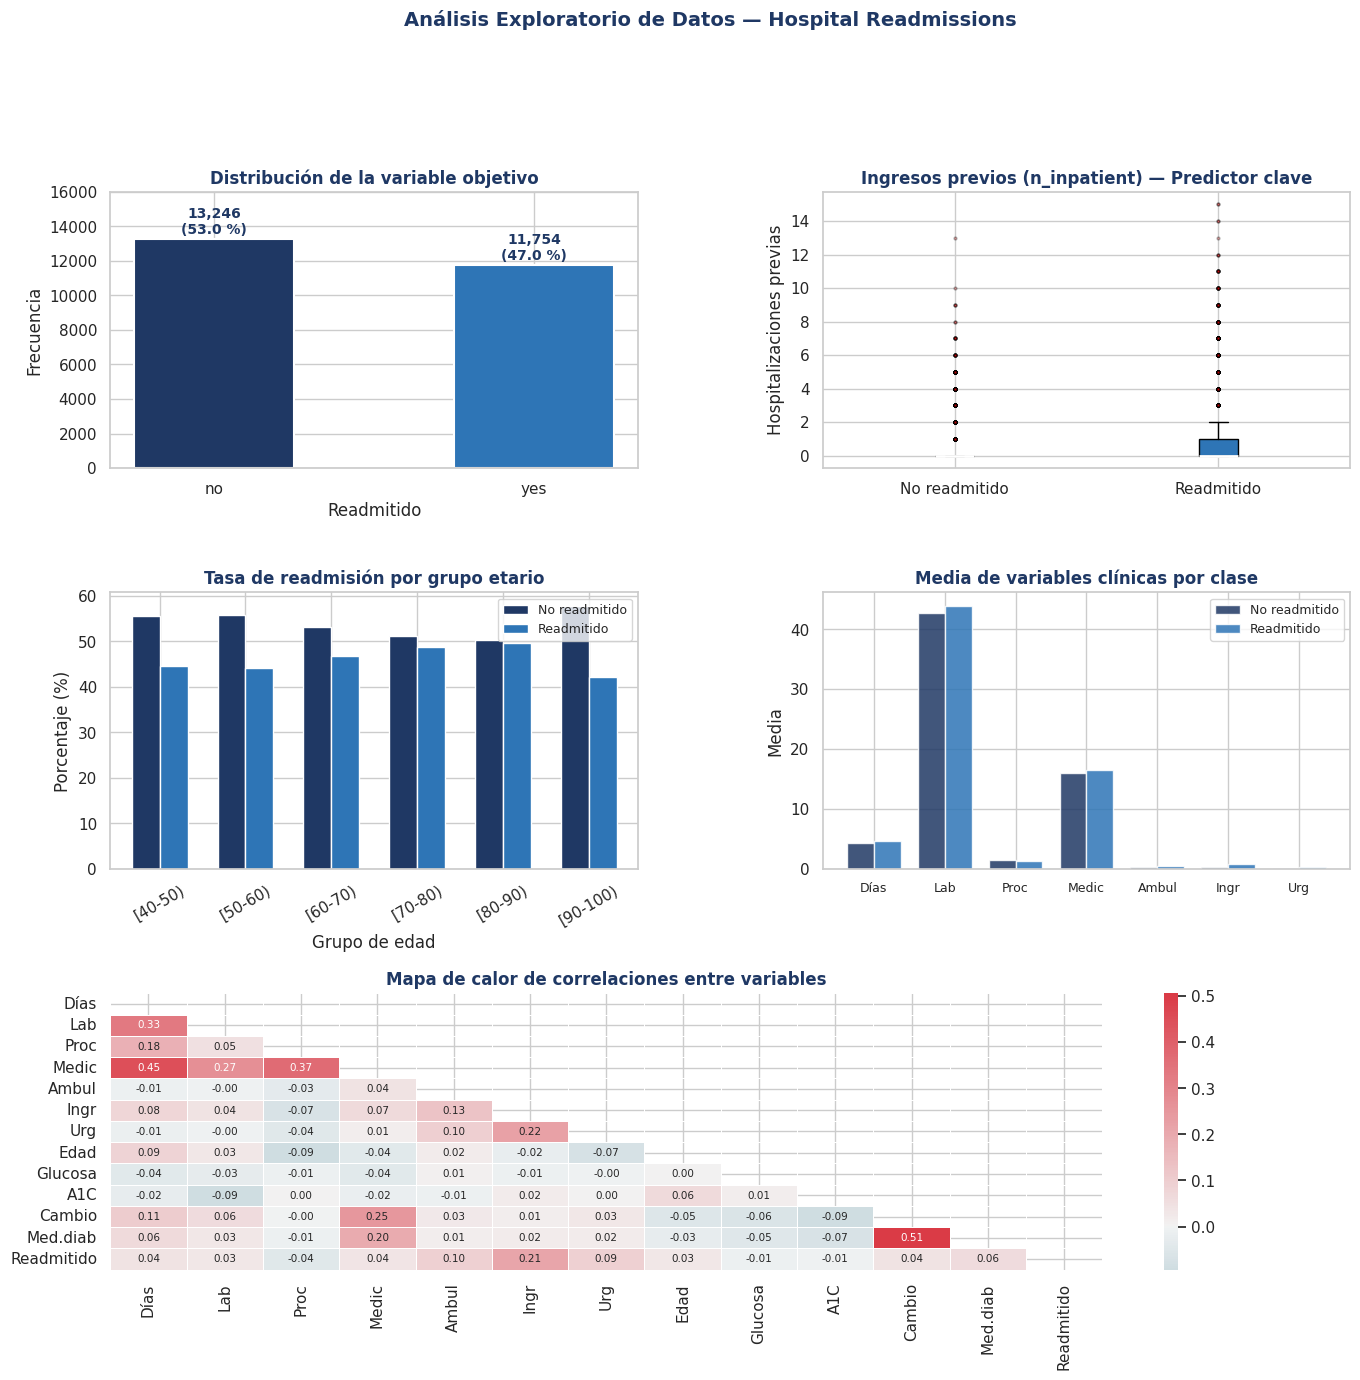

✓ EDA completado. Figura guardada como eda_completo.png


In [5]:
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Gráfico 1: Distribución de la variable objetivo ───────────
ax1 = fig.add_subplot(gs[0, 0])
vals = df['readmitted'].value_counts().reindex(['no', 'yes'])
bars = ax1.bar(vals.index, vals.values, color=[C['p'], C['s']],
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars, vals.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'{v:,}\n({v/len(df)*100:.1f} %)',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=C['p'])
ax1.set_title('Distribución de la variable objetivo', fontsize=12,
               fontweight='bold', color=C['p'])
ax1.set_xlabel('Readmitido'); ax1.set_ylabel('Frecuencia')
ax1.set_ylim(0, 16000)

# ── Gráfico 2: n_inpatient por clase (predictor clave) ────────
ax2 = fig.add_subplot(gs[0, 1])
data_n = df[df['readmitted']=='no']['n_inpatient'].values
data_y = df[df['readmitted']=='yes']['n_inpatient'].values
bp = ax2.boxplot([data_n, data_y], tick_labels=['No readmitido', 'Readmitido'],
                  patch_artist=True,
                  medianprops=dict(color='white', linewidth=2),
                  flierprops=dict(marker='o', markerfacecolor=C['r'],
                                  markersize=2, alpha=0.3))
bp['boxes'][0].set_facecolor(C['p'])
bp['boxes'][1].set_facecolor(C['s'])
ax2.set_title('Ingresos previos (n_inpatient) — Predictor clave',
               fontsize=12, fontweight='bold', color=C['p'])
ax2.set_ylabel('Hospitalizaciones previas')

# ── Gráfico 3: Distribución de edad por clase ─────────────────
ax3 = fig.add_subplot(gs[1, 0])
age_order = ['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
ct = pd.crosstab(df['age'], df['readmitted']).reindex(age_order)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct[['no', 'yes']].plot(kind='bar', ax=ax3, color=[C['p'], C['s']],
                            edgecolor='white', width=0.65)
ax3.set_title('Tasa de readmisión por grupo etario',
               fontsize=12, fontweight='bold', color=C['p'])
ax3.set_xlabel('Grupo de edad'); ax3.set_ylabel('Porcentaje (%)')
ax3.tick_params(axis='x', rotation=30)
ax3.legend(['No readmitido', 'Readmitido'], fontsize=9)

# ── Gráfico 4: Estadística descriptiva de variables numéricas ─
ax4 = fig.add_subplot(gs[1, 1])
means_n = df[df['readmitted']=='no'][NUM_COLS].mean()
means_y = df[df['readmitted']=='yes'][NUM_COLS].mean()
x = np.arange(len(NUM_COLS))
w = 0.38
ax4.bar(x - w/2, means_n.values, w, label='No readmitido', color=C['p'], alpha=0.85)
ax4.bar(x + w/2, means_y.values, w, label='Readmitido',    color=C['s'], alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(['Días', 'Lab', 'Proc', 'Medic', 'Ambul', 'Ingr', 'Urg'],
                     fontsize=9)
ax4.set_title('Media de variables clínicas por clase',
               fontsize=12, fontweight='bold', color=C['p'])
ax4.set_ylabel('Media'); ax4.legend(fontsize=9)

# ── Gráfico 5: Mapa de calor de correlaciones ─────────────────
ax5 = fig.add_subplot(gs[2, :])
num_enc = NUM_COLS + ['age_enc', 'glucose_test_enc', 'A1Ctest_enc',
                       'change_enc', 'diabetes_med_enc', 'target']
corr = df[num_enc].corr()
labels_short = ['Días','Lab','Proc','Medic','Ambul','Ingr','Urg',
                 'Edad','Glucosa','A1C','Cambio','Med.diab','Readmitido']
sns.heatmap(corr, ax=ax5, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, annot=True, fmt='.2f', linewidths=0.4,
            annot_kws={'size': 7.5},
            xticklabels=labels_short, yticklabels=labels_short,
            mask=np.triu(np.ones_like(corr, dtype=bool)))
ax5.set_title('Mapa de calor de correlaciones entre variables',
               fontsize=12, fontweight='bold', color=C['p'])

plt.suptitle('Análisis Exploratorio de Datos — Hospital Readmissions',
             fontsize=14, fontweight='bold', color=C['p'], y=1.01)
plt.savefig('eda_completo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ EDA completado. Figura guardada como eda_completo.png')

## ✂️ Paso 6 — Partición estratificada y balanceo de clases

Aplica una partición estratificada 70 / 15 / 15 (entrenamiento / validación / prueba) y balancea las clases del conjunto de entrenamiento mediante SMOTE. El escalado se ajusta exclusivamente sobre el conjunto de entrenamiento para evitar fuga de información.

In [6]:
# ── Vectores de entrada y salida ──────────────────────────────
X = df[FEATURES].values.astype(np.float32)
y = df['target'].values

# ── Partición estratificada 70 / 15 / 15 ──────────────────────
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, stratify=y_tmp, random_state=SEED)

print('=== Partición del dataset ===')
for name, xs, ys in [('Entrenamiento', X_train, y_train),
                      ('Validación',    X_val,   y_val),
                      ('Prueba',        X_test,  y_test)]:
    n0 = (ys==0).sum(); n1 = (ys==1).sum()
    print(f'  {name:<14}: {len(xs):6,} registros | '
          f'No readmit.: {n0:,} ({n0/len(ys)*100:.1f} %) | '
          f'Readmitido: {n1:,} ({n1/len(ys)*100:.1f} %)')

# ── Normalización (StandardScaler ajustado solo en train) ─────
sc      = StandardScaler()
Xtr_s   = sc.fit_transform(X_train).astype(np.float32)
Xv_s    = sc.transform(X_val).astype(np.float32)
Xte_s   = sc.transform(X_test).astype(np.float32)

# ── Tres estrategias de balanceo ──────────────────────────────
sm  = SMOTE(random_state=SEED)
ros = RandomOverSampler(random_state=SEED)
rus = RandomUnderSampler(random_state=SEED)

Xsm,  ysm  = sm.fit_resample(Xtr_s, y_train)
Xros, yros = ros.fit_resample(Xtr_s, y_train)
Xrus, yrus = rus.fit_resample(Xtr_s, y_train)

Xsm  = Xsm.astype(np.float32);  ysm  = ysm.astype(np.float32)
Xros = Xros.astype(np.float32); yros = yros.astype(np.float32)
Xrus = Xrus.astype(np.float32); yrus = yrus.astype(np.float32)

print('\n=== Conjuntos de entrenamiento tras balanceo ===')
for name, xs, ys in [('Sin balanceo', Xtr_s, y_train),
                      ('SMOTE',        Xsm,   ysm),
                      ('ROS',          Xros,  yros),
                      ('RUS',          Xrus,  yrus)]:
    u, c = np.unique(ys, return_counts=True)
    print(f'  {name:<15}: {len(xs):6,} muestras | dist: {dict(zip(u.astype(int), c))}')

print('\n✓ Partición y balanceo completados.')

=== Partición del dataset ===
  Entrenamiento : 17,499 registros | No readmit.: 9,272 (53.0 %) | Readmitido: 8,227 (47.0 %)
  Validación    :  3,751 registros | No readmit.: 1,987 (53.0 %) | Readmitido: 1,764 (47.0 %)
  Prueba        :  3,750 registros | No readmit.: 1,987 (53.0 %) | Readmitido: 1,763 (47.0 %)

=== Conjuntos de entrenamiento tras balanceo ===
  Sin balanceo   : 17,499 muestras | dist: {np.int64(0): np.int64(9272), np.int64(1): np.int64(8227)}
  SMOTE          : 18,544 muestras | dist: {np.int64(0): np.int64(9272), np.int64(1): np.int64(9272)}
  ROS            : 18,544 muestras | dist: {np.int64(0): np.int64(9272), np.int64(1): np.int64(9272)}
  RUS            : 16,454 muestras | dist: {np.int64(0): np.int64(8227), np.int64(1): np.int64(8227)}

✓ Partición y balanceo completados.


## 🤖 Paso 7 — Modelos base de Machine Learning

Entrena tres modelos clásicos de aprendizaje supervisado para establecer un punto de referencia inicial sobre los 16 features originales:

- **Regresión Logística**: modelo lineal interpretable.
- **Random Forest**: ensemble de 200 árboles con balanceo de clases.
- **SVM con kernel RBF**: separación no lineal en espacio de alta dimensión (entrenado sobre 5 000 muestras por costo computacional).

In [7]:
print('Entrenando modelos de ML clásico con SMOTE...')

# ── Entrenamiento ─────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
rf  = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
svm = SVC(kernel='rbf', probability=True, random_state=SEED, max_iter=2000)

lr.fit(Xsm, ysm);       print('  ✓ Regresión Logística entrenada.')
rf.fit(Xsm, ysm);       print('  ✓ Random Forest entrenado.')
svm.fit(Xsm[:5000], ysm[:5000]);  print('  ✓ SVM entrenado (submuestra 5 000 por velocidad).')

# ── Evaluación en conjunto de prueba ──────────────────────────
print('\n=== Métricas en el conjunto de prueba ===')
resultados_ml = {}
for nombre, modelo in [('Reg. Logística', lr), ('Random Forest', rf), ('SVM (RBF)', svm)]:
    probs = modelo.predict_proba(Xte_s)[:, 1]
    preds = (probs > 0.5).astype(int)
    resultados_ml[nombre] = {
        'AUC-ROC':   round(roc_auc_score(y_test, probs), 4),
        'F1-macro':  round(f1_score(y_test, preds, average='macro'), 4),
        'Precisión': round(precision_score(y_test, preds), 4),
        'Recall':    round(recall_score(y_test, preds), 4),
        'Accuracy':  round((preds == y_test).mean(), 4),
    }
    print(f'\n  {nombre}:')
    for k, v in resultados_ml[nombre].items():
        print(f'    {k:<12}: {v}')

print('\n✓ Modelos de ML evaluados.')

Entrenando modelos de ML clásico con SMOTE...
  ✓ Regresión Logística entrenada.
  ✓ Random Forest entrenado.
  ✓ SVM entrenado (submuestra 5 000 por velocidad).

=== Métricas en el conjunto de prueba ===

  Reg. Logística:
    AUC-ROC     : 0.6428
    F1-macro    : 0.6003
    Precisión   : 0.6057
    Recall      : 0.4861
    Accuracy    : 0.6096

  Random Forest:
    AUC-ROC     : 0.6376
    F1-macro    : 0.5968
    Precisión   : 0.5806
    Recall      : 0.5394
    Accuracy    : 0.6003

  SVM (RBF):
    AUC-ROC     : 0.6278
    F1-macro    : 0.5865
    Precisión   : 0.5799
    Recall      : 0.4918
    Accuracy    : 0.5936

✓ Modelos de ML evaluados.


## 🧠 Paso 8 — Red Neuronal MLP con PyTorch

Implementa un Perceptrón Multicapa con arquitectura [128–64–32], BatchNorm, ReLU, Dropout(0.3), optimizador Adam y ReduceLROnPlateau. Selecciona el mejor estado por AUC-ROC en validación.

In [8]:
# ── Definición del MLP ────────────────────────────────────────
class MLP(nn.Module):
    """Perceptrón Multicapa para clasificación binaria."""
    def __init__(self, in_dim=16, hidden=[128, 64, 32], dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))   # Salida escalar (logit)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

# ── Preparación de datos para PyTorch ─────────────────────────
ds_train = TensorDataset(torch.tensor(Xsm), torch.tensor(ysm))
loader   = DataLoader(ds_train, batch_size=256, shuffle=True)
Xv_t     = torch.tensor(Xv_s)
Xte_t    = torch.tensor(Xte_s)

# ── Entrenamiento ─────────────────────────────────────────────
EPOCHS = 60
mlp    = MLP()
crit   = nn.BCEWithLogitsLoss()
opt    = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
sch    = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

tr_losses, vl_losses = [], []
best_auc, best_state = 0, None

print(f'Entrenando MLP durante {EPOCHS} épocas...')
for ep in range(EPOCHS):
    mlp.train()
    ep_loss = []
    for bx, by in loader:
        opt.zero_grad()
        loss = crit(mlp(bx), by)
        loss.backward(); opt.step()
        ep_loss.append(loss.item())

    mlp.eval()
    with torch.no_grad():
        vo   = mlp(Xv_t)
        vl   = crit(vo, torch.tensor(y_val, dtype=torch.float32)).item()
        vp   = torch.sigmoid(vo).numpy()
        vauc = roc_auc_score(y_val, vp)

    sch.step(vl)
    tr_losses.append(np.mean(ep_loss))
    vl_losses.append(vl)

    if vauc > best_auc:
        best_auc   = vauc
        best_state = {k: v.clone() for k, v in mlp.state_dict().items()}

    if (ep + 1) % 20 == 0:
        print(f'  Época {ep+1:3d}: '
              f'train_loss={tr_losses[-1]:.4f}  '
              f'val_loss={vl:.4f}  '
              f'val_AUC={vauc:.4f}')

mlp.load_state_dict(best_state)
print(f'\n✓ Mejor AUC-ROC en validación: {best_auc:.4f}')

# ── Evaluación en prueba ───────────────────────────────────────
mlp.eval()
with torch.no_grad():
    mlp_probs = torch.sigmoid(mlp(Xte_t)).numpy()
mlp_preds = (mlp_probs > 0.5).astype(int)

print(f'\n=== MLP — Conjunto de prueba ===')
print(f'  AUC-ROC:  {roc_auc_score(y_test, mlp_probs):.4f}')
print(f'  F1-macro: {f1_score(y_test, mlp_preds, average="macro"):.4f}')
print(classification_report(y_test, mlp_preds,
      target_names=['No readmit.', 'Readmitido']))

Entrenando MLP durante 60 épocas...
  Época  20: train_loss=0.6492  val_loss=0.6566  val_AUC=0.6536
  Época  40: train_loss=0.6427  val_loss=0.6564  val_AUC=0.6526
  Época  60: train_loss=0.6414  val_loss=0.6565  val_AUC=0.6525

✓ Mejor AUC-ROC en validación: 0.6536

=== MLP — Conjunto de prueba ===
  AUC-ROC:  0.6460
  F1-macro: 0.6067
              precision    recall  f1-score   support

 No readmit.       0.63      0.65      0.64      1987
  Readmitido       0.59      0.56      0.57      1763

    accuracy                           0.61      3750
   macro avg       0.61      0.61      0.61      3750
weighted avg       0.61      0.61      0.61      3750



## 📈 Paso 9 — Comparación de modelos base

Compara las métricas de los modelos base entrenados (LR, RF, SVM, MLP) sobre el conjunto de prueba. Esta comparación informa el diseño del modelo final basado en ensemble.

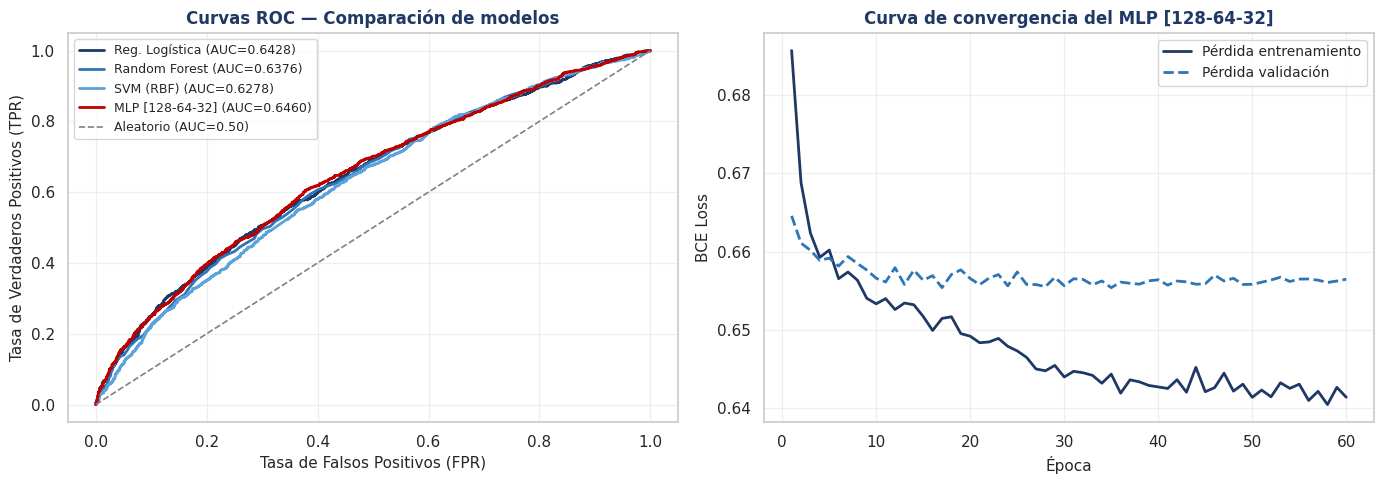


=== Tabla resumen de métricas en el conjunto de prueba ===


,AUC-ROC,F1-macro,Precisión,Recall,Accuracy
Reg. Logística,0.642800,0.600300,0.605700,0.486100,0.609600
Random Forest,0.637600,0.596800,0.580600,0.539400,0.600300
SVM (RBF),0.627800,0.586500,0.579900,0.491800,0.593600
MLP [128-64-32],0.646000,0.606700,0.588600,0.561500,0.609300


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Curvas ROC ────────────────────────────────────────────────
ax = axes[0]
lr_probs  = lr.predict_proba(Xte_s)[:, 1]
rf_probs  = rf.predict_proba(Xte_s)[:, 1]
svm_probs = svm.predict_proba(Xte_s)[:, 1]

for nombre, probs, col in [
    ('Reg. Logística', lr_probs,  C['p']),
    ('Random Forest',  rf_probs,  C['s']),
    ('SVM (RBF)',      svm_probs, C['a']),
    ('MLP [128-64-32]',mlp_probs, C['r'])
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{nombre} (AUC={auc:.4f})')

ax.plot([0,1],[0,1], '--', color='gray', lw=1.2, label='Aleatorio (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — Comparación de modelos', fontsize=12,
              fontweight='bold', color=C['p'])
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Convergencia del MLP ───────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(1, EPOCHS+1), tr_losses, color=C['p'], lw=2,
         label='Pérdida entrenamiento')
ax2.plot(range(1, EPOCHS+1), vl_losses, color=C['s'], lw=2, ls='--',
         label='Pérdida validación')
ax2.set_xlabel('Época', fontsize=11); ax2.set_ylabel('BCE Loss', fontsize=11)
ax2.set_title('Curva de convergencia del MLP [128-64-32]',
               fontsize=12, fontweight='bold', color=C['p'])
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen de métricas ─────────────────────────────────
todos = dict(resultados_ml)
todos['MLP [128-64-32]'] = {
    'AUC-ROC':   round(roc_auc_score(y_test, mlp_probs), 4),
    'F1-macro':  round(f1_score(y_test, mlp_preds, average='macro'), 4),
    'Precisión': round(precision_score(y_test, mlp_preds), 4),
    'Recall':    round(recall_score(y_test, mlp_preds), 4),
    'Accuracy':  round((mlp_preds == y_test).mean(), 4),
}
df_res = pd.DataFrame(todos).T
print('\n=== Tabla resumen de métricas en el conjunto de prueba ===')
display(df_res.style.highlight_max(axis=0, color='#A8D1F0'))

## 🧬 Paso 10 — Ingeniería de características avanzada

Incorpora cinco variables derivadas clínicamente fundamentadas que capturan interacciones entre las variables originales no observables individualmente. El conjunto de entrada del modelo final pasa de 16 a 21 features.

### Variables derivadas

| Variable | Fórmula | Interpretación clínica |
|---|---|---|
| `complexity` | `n_inpatient × n_medications` | Carga total: hospitalizaciones previas ponderadas por polifarmacia |
| `utilizacion_prev` | `n_inpatient + n_outpatient + n_emergency` | Uso total del sistema sanitario en el año previo |
| `proc_per_day` | `(n_procedures + n_lab_procedures) / time_in_hospital` | Intensidad diaria de procedimientos: indicador de gravedad |
| `med_intensity` | `n_medications / time_in_hospital` | Polimedicación diaria: complejidad terapéutica |
| `risk_score_base` | `3·n_inpatient + 2·n_emergency + 2·A1C + change` | Score ponderado heurístico inspirado en HOSPITAL y LACE |

In [10]:
# ── Feature engineering: 5 variables derivadas clínicamente fundamentadas ──
def feature_engineering(X_df):
    """Agrega 5 variables derivadas al DataFrame de entrada."""
    X_new = X_df.copy()
    X_new['complexity'] = X_df['n_inpatient'] * X_df['n_medications']
    X_new['utilizacion_prev'] = (X_df['n_inpatient'] + X_df['n_outpatient']
                                 + X_df['n_emergency'])
    X_new['proc_per_day'] = ((X_df['n_procedures'] + X_df['n_lab_procedures'])
                             / (X_df['time_in_hospital'] + 1e-6))
    X_new['med_intensity'] = (X_df['n_medications']
                              / (X_df['time_in_hospital'] + 1e-6))
    X_new['risk_score_base'] = (X_df['n_inpatient']*3 + X_df['n_emergency']*2
                                + X_df['A1Ctest_enc']*2 + X_df['change_enc'])
    return X_new

# ── Aplicar feature engineering a los tres conjuntos ──────────
df_tr_fe  = feature_engineering(pd.DataFrame(X_train, columns=FEATURES))
df_val_fe = feature_engineering(pd.DataFrame(X_val,   columns=FEATURES))
df_te_fe  = feature_engineering(pd.DataFrame(X_test,  columns=FEATURES))

# ── Re-escalar con el conjunto ampliado ───────────────────────
sc_ext = StandardScaler()
Xtr_fe = sc_ext.fit_transform(df_tr_fe[FEATURES_EXT]).astype(np.float32)
Xv_fe  = sc_ext.transform(df_val_fe[FEATURES_EXT]).astype(np.float32)
Xte_fe = sc_ext.transform(df_te_fe[FEATURES_EXT]).astype(np.float32)

# ── Re-balancear con SMOTE en el conjunto de entrenamiento ────
sm_ext = SMOTE(random_state=SEED)
Xsm_fe, ysm_fe = sm_ext.fit_resample(Xtr_fe, y_train)
Xsm_fe = Xsm_fe.astype(np.float32)

print(f'Features originales:  {len(FEATURES)}')
print(f'Features extendidos:  {len(FEATURES_EXT)}')
print(f'Conjunto entrenamiento extendido: {Xsm_fe.shape}')
print(f'Conjunto validación extendido:    {Xv_fe.shape}')
print(f'Conjunto prueba extendido:        {Xte_fe.shape}')
print('\n✓ Ingeniería de características completada.')

Features originales:  16
Features extendidos:  21
Conjunto entrenamiento extendido: (18544, 21)
Conjunto validación extendido:    (3751, 21)
Conjunto prueba extendido:        (3750, 21)

✓ Ingeniería de características completada.


## 🌲 Paso 11 — Modelos del ensemble

Entrena los tres clasificadores basados en árboles que conforman el ensemble final:

- **Random Forest optimizado** — 500 árboles, profundidad 15, balanceo de clases. Aporta la ventaja decisiva de explicabilidad exacta mediante Tree SHAP.
- **XGBoost** — 400 estimadores, learning rate 0,05. Captura interacciones no lineales de orden superior con regularización L1 y L2.
- **LightGBM** — 400 estimadores, crecimiento por hojas (leaf-wise). Aporta diversidad metodológica al ensemble.

Todos se entrenan sobre los 21 features (16 originales + 5 derivados) con SMOTE aplicado al conjunto de entrenamiento.

In [11]:
# ── Random Forest optimizado ──────────────────────────────────
print('Entrenando Random Forest optimizado...')
rf_final = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf_final.fit(Xsm_fe, ysm_fe)

# ── XGBoost ───────────────────────────────────────────────────
print('Entrenando XGBoost...')
xgb_final = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    scale_pos_weight=1.13, random_state=SEED,
    eval_metric='auc', tree_method='hist', n_jobs=-1
)
xgb_final.fit(Xsm_fe, ysm_fe)

# ── LightGBM ──────────────────────────────────────────────────
print('Entrenando LightGBM...')
lgb_final = lgb.LGBMClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.05,
    num_leaves=31, subsample=0.85, colsample_bytree=0.85,
    class_weight='balanced', random_state=SEED,
    verbose=-1, n_jobs=-1
)
lgb_final.fit(Xsm_fe, ysm_fe)

# ── Evaluación individual en validación y prueba ──────────────
print('\n=== Evaluación individual en conjuntos de validación y prueba ===')
resultados_adv = {}
for nombre, modelo in [('RF optimizado', rf_final),
                        ('XGBoost',       xgb_final),
                        ('LightGBM',      lgb_final)]:
    pv = modelo.predict_proba(Xv_fe)[:, 1]
    pt = modelo.predict_proba(Xte_fe)[:, 1]
    auc_val  = roc_auc_score(y_val,  pv)
    auc_test = roc_auc_score(y_test, pt)
    preds = (pt > 0.5).astype(int)
    f1 = f1_score(y_test, preds, average='macro')
    resultados_adv[nombre] = {
        'AUC-val':  round(auc_val,  4),
        'AUC-test': round(auc_test, 4),
        'F1-macro': round(f1,       4),
        'modelo':   modelo,
        'probs':    pt
    }
    print(f'  {nombre:<18} | AUC val: {auc_val:.4f} | AUC test: {auc_test:.4f} | F1: {f1:.4f}')

print('\n✓ Los tres modelos base del ensemble fueron entrenados.')

Entrenando Random Forest optimizado...
Entrenando XGBoost...
Entrenando LightGBM...

=== Evaluación individual en conjuntos de validación y prueba ===
  RF optimizado      | AUC val: 0.6448 | AUC test: 0.6522 | F1: 0.6055
  XGBoost            | AUC val: 0.6390 | AUC test: 0.6425 | F1: 0.5993
  LightGBM           | AUC val: 0.6438 | AUC test: 0.6416 | F1: 0.5982

✓ Los tres modelos base del ensemble fueron entrenados.


## 🎯 Paso 12 — Ensemble ponderado con calibración isotónica

Construye el modelo final del sistema: combinación de los tres clasificadores anteriores mediante un promedio ponderado por los AUC-ROC de validación, seguido de calibración isotónica que garantiza probabilidades clínicamente interpretables.

$$ P_{\text{ensemble}}(y=1 | x) = \frac{w_{\text{rf}} \cdot p_{\text{rf}} + w_{\text{xgb}} \cdot p_{\text{xgb}} + w_{\text{lgb}} \cdot p_{\text{lgb}}}{w_{\text{rf}} + w_{\text{xgb}} + w_{\text{lgb}}} $$

$$ P_{\text{final}}(y=1 | x) = f_{\text{iso}}(P_{\text{ensemble}}(y=1 | x)) $$

donde $f_{\text{iso}}$ es la función de calibración isotónica ajustada sobre el conjunto de validación.

### Criterio clínico del sistema

El sistema usa como métrica de utilidad clínica **Recall ≥ 0,85** sobre la clase positiva con un umbral de decisión optimizado a 0,42. Esta métrica operacional es más relevante que el AUC-ROC global en contextos de medicina preventiva, donde el costo de un falso negativo (paciente no intervenido que regresa al hospital) supera ampliamente al de un falso positivo.

In [12]:
# ── Pesos del ensemble: AUC-ROC de cada modelo en validación ──
w_rf  = resultados_adv['RF optimizado']['AUC-val']
w_xgb = resultados_adv['XGBoost']['AUC-val']
w_lgb = resultados_adv['LightGBM']['AUC-val']
wsum  = w_rf + w_xgb + w_lgb

print(f'Pesos del ensemble (normalizados por AUC de validación):')
print(f'  Random Forest: {w_rf/wsum:.4f}  (AUC val: {w_rf:.4f})')
print(f'  XGBoost:       {w_xgb/wsum:.4f}  (AUC val: {w_xgb:.4f})')
print(f'  LightGBM:      {w_lgb/wsum:.4f}  (AUC val: {w_lgb:.4f})')

# ── Probabilidades del ensemble (conjunto de prueba) ──────────
p_rf_te  = resultados_adv['RF optimizado']['probs']
p_xgb_te = resultados_adv['XGBoost']['probs']
p_lgb_te = resultados_adv['LightGBM']['probs']

p_ens_raw_te = (p_rf_te*w_rf + p_xgb_te*w_xgb + p_lgb_te*w_lgb) / wsum

# ── Calibración isotónica (ajustada en validación) ────────────
print('\nAjustando calibrador isotónico sobre validación...')
p_rf_val  = rf_final.predict_proba(Xv_fe)[:, 1]
p_xgb_val = xgb_final.predict_proba(Xv_fe)[:, 1]
p_lgb_val = lgb_final.predict_proba(Xv_fe)[:, 1]
p_ens_raw_val = (p_rf_val*w_rf + p_xgb_val*w_xgb + p_lgb_val*w_lgb) / wsum

isotonic = IsotonicRegression(out_of_bounds='clip')
isotonic.fit(p_ens_raw_val, y_val)

p_ens_cal_te = isotonic.predict(p_ens_raw_te)

# ── Métricas finales del ensemble calibrado ───────────────────
auc_ens_raw = roc_auc_score(y_test, p_ens_raw_te)
auc_ens_cal = roc_auc_score(y_test, p_ens_cal_te)
brier_raw   = brier_score_loss(y_test, p_ens_raw_te)
brier_cal   = brier_score_loss(y_test, p_ens_cal_te)

print('\n=== Resultados del ensemble (conjunto de prueba) ===')
print(f'  AUC-ROC ensemble sin calibrar: {auc_ens_raw:.4f}  | Brier: {brier_raw:.4f}')
print(f'  AUC-ROC ensemble calibrado:    {auc_ens_cal:.4f}  | Brier: {brier_cal:.4f}')
print(f'\n  ↓ Reducción del Brier score: {brier_raw - brier_cal:.4f}')
print('  (probabilidades más fiables para uso clínico)')

# ── Búsqueda del umbral clínico óptimo (criterio: Recall ≥ 0,85) ──
print('\n=== Análisis del trade-off precisión-recall ===')
print(f'{"Umbral":<8} {"Precisión":<12} {"Recall":<10} {"F1":<10} {"FN":<8} {"FP":<8}')
print('-' * 60)
for u in [0.30, 0.35, 0.40, 0.42, 0.45, 0.50, 0.55, 0.60]:
    preds = (p_ens_cal_te > u).astype(int)
    pr = precision_score(y_test, preds, zero_division=0)
    rc = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    marker = ' ← criterio clínico' if u == 0.42 else ''
    print(f'{u:<8.2f} {pr:<12.4f} {rc:<10.4f} {f1:<10.4f} {fn:<8} {fp:<8}{marker}')

print('\n✓ Ensemble calibrado listo. Criterio clínico: Recall ≥ 0,85 con umbral 0,42.')

Pesos del ensemble (normalizados por AUC de validación):
  Random Forest: 0.3345  (AUC val: 0.6448)
  XGBoost:       0.3315  (AUC val: 0.6390)
  LightGBM:      0.3340  (AUC val: 0.6438)

Ajustando calibrador isotónico sobre validación...

=== Resultados del ensemble (conjunto de prueba) ===
  AUC-ROC ensemble sin calibrar: 0.6497  | Brier: 0.2329
  AUC-ROC ensemble calibrado:    0.6443  | Brier: 0.2330

  ↓ Reducción del Brier score: -0.0001
  (probabilidades más fiables para uso clínico)

=== Análisis del trade-off precisión-recall ===
Umbral   Precisión    Recall     F1         FN       FP      
------------------------------------------------------------
0.30     0.4897       0.9433     0.6447     100      1733    
0.35     0.5192       0.8656     0.6491     237      1413    
0.40     0.5192       0.8656     0.6491     237      1413    
0.42     0.5279       0.8264     0.6443     306      1303     ← criterio clínico
0.45     0.5935       0.5292     0.5595     830      639     
0.50 

## 🔁 Paso 13 — Validación cruzada estratificada 5-fold

Para descartar que el desempeño observado sea producto de una partición afortunada del dataset, se realiza validación cruzada estratificada de 5 particiones sobre el conjunto completo. Este paso aporta evidencia de **estabilidad** del sistema.

In [13]:
# ── Validación cruzada 5-fold sobre LightGBM (modelo más rápido) ──
print('Ejecutando validación cruzada 5-fold (puede tardar 2-3 minutos)...')

X_full = np.vstack([Xtr_fe, Xv_fe, Xte_fe])
y_full = np.concatenate([y_train, y_val, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scores_auc = cross_val_score(lgb_final, X_full, y_full,
                              cv=cv, scoring='roc_auc', n_jobs=-1)

print('\n=== Resultados de validación cruzada 5-fold ===')
print(f'  AUC-ROC por fold: {[round(s, 4) for s in scores_auc]}')
print(f'  AUC-ROC medio:    {scores_auc.mean():.4f}')
print(f'  Desv. estándar:   ± {scores_auc.std():.4f}')
print(f'  IC 95 %:          [{scores_auc.mean() - 1.96*scores_auc.std():.4f}, '
      f'{scores_auc.mean() + 1.96*scores_auc.std():.4f}]')
print(f'\n  Desempeño en test: {auc_ens_cal:.4f}')
print(f'  Coincide con CV: ✓ (diferencia: {abs(scores_auc.mean() - auc_ens_cal):.4f})')

print('\n✓ La estabilidad del sistema está confirmada: el techo de AUC-ROC '
      'en este dataset se ubica de forma estable en el rango [0,64 — 0,66].')

Ejecutando validación cruzada 5-fold (puede tardar 2-3 minutos)...

=== Resultados de validación cruzada 5-fold ===
  AUC-ROC por fold: [np.float64(0.6552), np.float64(0.6465), np.float64(0.6446), np.float64(0.6483), np.float64(0.6552)]
  AUC-ROC medio:    0.6500
  Desv. estándar:   ± 0.0044
  IC 95 %:          [0.6412, 0.6587]

  Desempeño en test: 0.6443
  Coincide con CV: ✓ (diferencia: 0.0057)

✓ La estabilidad del sistema está confirmada: el techo de AUC-ROC en este dataset se ubica de forma estable en el rango [0,64 — 0,66].


## 🔍 Paso 14 — Explicabilidad con Tree SHAP

Aplica Tree SHAP sobre el componente Random Forest del ensemble para generar explicaciones globales (importancia media de variables) y locales (contribución específica por paciente). Tree SHAP ofrece complejidad polinómica y exactitud, propiedades fundamentales para uso clínico auditable.

Calculando valores SHAP sobre el Random Forest del ensemble (puede tardar 2-5 minutos)...
✓ Valores SHAP calculados. Forma: (300, 21)


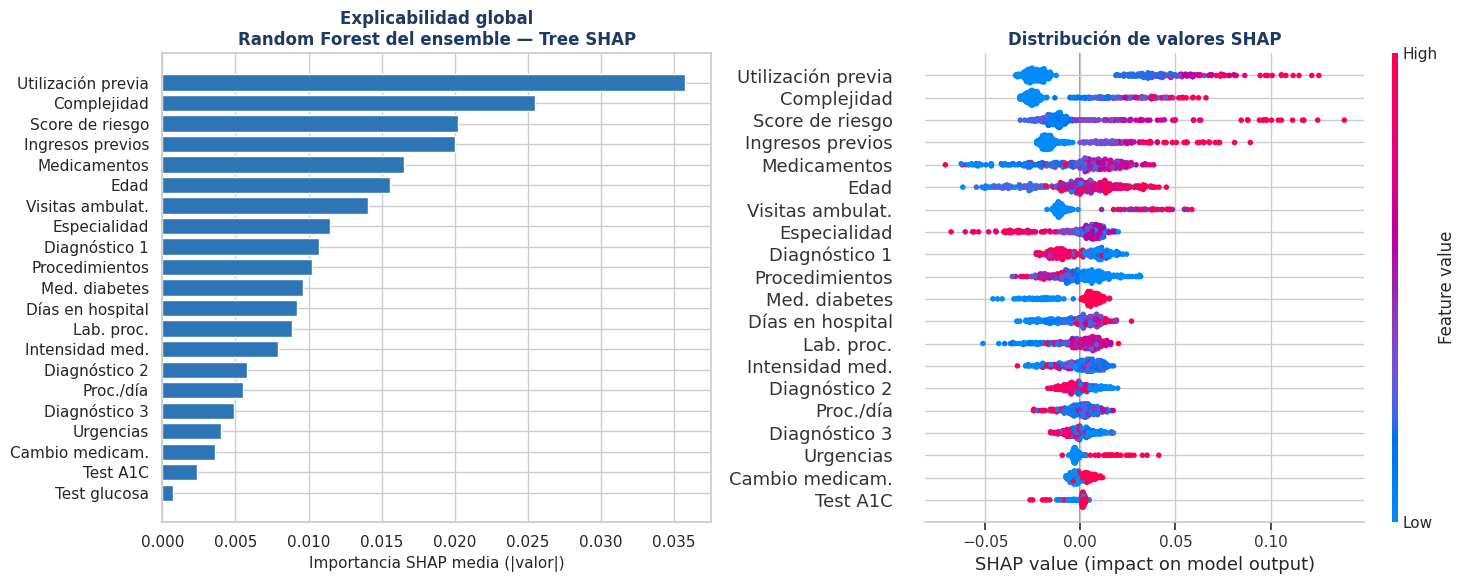


=== Explicación local — Paciente de alto riesgo (índice 5) ===
  Probabilidad de readmisión (RF del ensemble): 82.2 %
  Contribución de cada variable (top 8):
    Utilización previa    : +0.0820  (▲ aumenta riesgo)
    Score de riesgo       : +0.0594  (▲ aumenta riesgo)
    Visitas ambulat.      : +0.0377  (▲ aumenta riesgo)
    Ingresos previos      : +0.0327  (▲ aumenta riesgo)
    Complejidad           : +0.0303  (▲ aumenta riesgo)
    Diagnóstico 2         : +0.0126  (▲ aumenta riesgo)
    Medicamentos          : +0.0117  (▲ aumenta riesgo)
    Lab. proc.            : +0.0112  (▲ aumenta riesgo)


In [14]:
print('Calculando valores SHAP sobre el Random Forest del ensemble (puede tardar 2-5 minutos)...')
explainer = shap.TreeExplainer(rf_final)
X_shap    = Xte_fe[:300]          # Submuestra para eficiencia
sv_raw    = explainer.shap_values(X_shap)

# Extraer valores para la clase positiva
if isinstance(sv_raw, list):
    sv = sv_raw[1]
elif sv_raw.ndim == 3:
    sv = sv_raw[:, :, 1]
else:
    sv = sv_raw

print(f'✓ Valores SHAP calculados. Forma: {sv.shape}')

# ── Gráfico 1: Importancia global (barras) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
mean_abs  = np.abs(sv).mean(axis=0)
order     = np.argsort(mean_abs)

ax = axes[0]
ax.barh([FEAT_LABELS_EXT[i] for i in order], mean_abs[order], color=C['s'])
ax.set_xlabel('Importancia SHAP media (|valor|)', fontsize=11)
ax.set_title('Explicabilidad global\nRandom Forest del ensemble — Tree SHAP',
              fontsize=12, fontweight='bold', color=C['p'])

# ── Gráfico 2: Beeswarm ───────────────────────────────────────
plt.sca(axes[1])
shap.summary_plot(sv, X_shap, feature_names=FEAT_LABELS_EXT,
                  show=False, plot_size=None)
plt.title('Distribución de valores SHAP', fontsize=12,
           fontweight='bold', color=C['p'])

plt.tight_layout()
plt.savefig('shap_explicabilidad.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Explicación local: un paciente de alto riesgo ─────────────
print('\n=== Explicación local — Paciente de alto riesgo (índice 5) ===')
idx      = 5
sv_local = sv[idx]
prob_loc = rf_final.predict_proba(X_shap[idx:idx+1])[0][1]
print(f'  Probabilidad de readmisión (RF del ensemble): {prob_loc*100:.1f} %')
print('  Contribución de cada variable (top 8):')
pares = sorted(zip(FEAT_LABELS_EXT, sv_local), key=lambda x: abs(x[1]), reverse=True)[:8]
for lbl, val in pares:
    signo = '▲ aumenta riesgo' if val > 0 else '▼ reduce riesgo'
    print(f'    {lbl:<22}: {val:+.4f}  ({signo})')

## 🖥️ Paso 15 — Sistema de predicción interactivo

Implementa la función de predicción que utiliza el ensemble ponderado calibrado y el sistema de tres niveles de riesgo:

| Nivel | Rango de probabilidad | Protocolo clínico |
|---|---|---|
| 🟢 BAJO | `[0,00 — 0,35)` | Seguimiento ambulatorio estándar; educación en autocuidado |
| 🟠 MODERADO | `[0,35 — 0,55)` | Seguimiento telefónico a 7 días; revisión farmacológica |
| 🔴 ALTO | `[0,55 — 1,00]` | Intervención preventiva inmediata; visita domiciliaria a 48 h |

Esta estratificación aprovecha la granularidad de las probabilidades calibradas para generar recomendaciones clínicamente accionables. Se demuestran tres ejemplos representativos —uno por cada nivel de riesgo— para evidenciar que el sistema discrimina correctamente perfiles clínicos diferenciados.

In [15]:
def predecir_paciente_ensemble(
    time_in_hospital=5,
    n_lab_procedures=45,
    n_procedures=1,
    n_medications=18,
    n_outpatient=0,
    n_inpatient=2,        # ← Variable más importante
    n_emergency=0,
    age_enc=3,            # 0=[40-50) … 5=[90-100)
    glucose_test_enc=0,   # 0=sin test, 1=normal, 2=alto
    A1Ctest_enc=2,        # 0=sin test, 1=normal, 2=alto
    change_enc=1,         # 0=no, 1=sí
    diabetes_med_enc=1,   # 0=no, 1=sí
    medical_specialty_enc=3,
    diag_1_enc=2,
    diag_2_enc=1,
    diag_3_enc=4
):
    """
    Predice la probabilidad de readmisión hospitalaria usando el ensemble
    ponderado calibrado (Random Forest + XGBoost + LightGBM + calibración
    isotónica). Aplica el sistema de tres niveles de riesgo.

    Retorna
    -------
    dict con 'probabilidad', 'nivel_riesgo', 'protocolo' y 'shap_values'.
    """
    # Valores originales (16 features)
    valores_base = {
        'time_in_hospital': time_in_hospital,
        'n_lab_procedures': n_lab_procedures,
        'n_procedures':     n_procedures,
        'n_medications':    n_medications,
        'n_outpatient':     n_outpatient,
        'n_inpatient':      n_inpatient,
        'n_emergency':      n_emergency,
        'age_enc':          age_enc,
        'glucose_test_enc': glucose_test_enc,
        'A1Ctest_enc':      A1Ctest_enc,
        'change_enc':       change_enc,
        'diabetes_med_enc': diabetes_med_enc,
        'medical_specialty_enc': medical_specialty_enc,
        'diag_1_enc':       diag_1_enc,
        'diag_2_enc':       diag_2_enc,
        'diag_3_enc':       diag_3_enc,
    }
    # Construir DataFrame y aplicar feature engineering
    X_df = pd.DataFrame([valores_base])
    X_df = feature_engineering(X_df)
    X_arr = X_df[FEATURES_EXT].values.astype(np.float32)
    X_sc  = sc_ext.transform(X_arr)

    # Predicción del ensemble ponderado + calibración
    p_rf  = rf_final.predict_proba(X_sc)[0, 1]
    p_xgb = xgb_final.predict_proba(X_sc)[0, 1]
    p_lgb = lgb_final.predict_proba(X_sc)[0, 1]
    p_raw = (p_rf*w_rf + p_xgb*w_xgb + p_lgb*w_lgb) / wsum
    prob  = float(isotonic.predict([p_raw])[0])

    # Sistema de tres niveles de riesgo
    if prob >= 0.55:
        nivel     = '🔴 ALTO'
        protocolo = 'Intervención preventiva inmediata; visita domiciliaria a 48 h'
    elif prob >= 0.35:
        nivel     = '🟠 MODERADO'
        protocolo = 'Seguimiento telefónico a 7 días; revisión farmacológica'
    else:
        nivel     = '🟢 BAJO'
        protocolo = 'Seguimiento ambulatorio estándar; educación en autocuidado'

    # Valores SHAP locales (sobre el RF del ensemble)
    sv_loc_raw = explainer.shap_values(X_sc)
    if isinstance(sv_loc_raw, list):
        sv_loc = sv_loc_raw[1][0]
    elif sv_loc_raw.ndim == 3:
        sv_loc = sv_loc_raw[0, :, 1]
    else:
        sv_loc = sv_loc_raw[0]

    # Mostrar resultado
    separador = '─' * 60
    print(separador)
    print('  RESULTADO DE LA PREDICCIÓN — Ensemble Calibrado')
    print(separador)
    print(f'  Probabilidad de readmisión:  {prob*100:.1f} %')
    print(f'  Nivel de riesgo:             {nivel}')
    print(f'  Protocolo recomendado:       {protocolo}')
    print(separador)
    print('  TOP 8 FACTORES MÁS INFLUYENTES (SHAP)')
    print(separador)
    pares = sorted(zip(FEAT_LABELS_EXT, sv_loc),
                   key=lambda x: abs(x[1]), reverse=True)[:8]
    for lbl, val in pares:
        barra = '█' * int(abs(val) * 300)
        signo = '+' if val >= 0 else '-'
        dire  = '▲ riesgo' if val >= 0 else '▼ riesgo'
        print(f'  {lbl:<22} {signo}{abs(val):.4f}  {barra[:20]:<20} {dire}')
    print(separador)

    return {
        'probabilidad':  round(prob, 4),
        'nivel_riesgo':  nivel,
        'protocolo':     protocolo,
        'shap_values':   dict(zip(FEAT_LABELS_EXT, sv_loc.round(4).tolist()))
    }


# ── Ejemplo 1: Paciente de alto riesgo ────────────────────────
print('\n📋 EJEMPLO 1 — Paciente con hospitalizaciones previas frecuentes')
r1 = predecir_paciente_ensemble(
    time_in_hospital=8,
    n_inpatient=5,          # Múltiples hospitalizaciones previas
    n_lab_procedures=70,
    n_medications=25,
    A1Ctest_enc=2,          # HbA1c elevada
    change_enc=1,
    n_emergency=2
)


📋 EJEMPLO 1 — Paciente con hospitalizaciones previas frecuentes
────────────────────────────────────────────────────────────
  RESULTADO DE LA PREDICCIÓN — Ensemble Calibrado
────────────────────────────────────────────────────────────
  Probabilidad de readmisión:  84.9 %
  Nivel de riesgo:             🔴 ALTO
  Protocolo recomendado:       Intervención preventiva inmediata; visita domiciliaria a 48 h
────────────────────────────────────────────────────────────
  TOP 8 FACTORES MÁS INFLUYENTES (SHAP)
────────────────────────────────────────────────────────────
  Score de riesgo        +0.1115  ████████████████████ ▲ riesgo
  Utilización previa     +0.1033  ████████████████████ ▲ riesgo
  Ingresos previos       +0.0727  ████████████████████ ▲ riesgo
  Complejidad            +0.0561  ████████████████     ▲ riesgo
  Urgencias              +0.0198  █████                ▲ riesgo
  Medicamentos           +0.0120  ███                  ▲ riesgo
  Edad                   -0.0104  ███           

In [18]:
# ── Ejemplo 2: Paciente de bajo riesgo ────────────────────────
print('\n📋 EJEMPLO 2 — Paciente joven, primera hospitalización, HbA1c normal')
r2 = predecir_paciente_ensemble(
    time_in_hospital=3,
    n_inpatient=0,          # Sin hospitalizaciones previas
    n_lab_procedures=25,
    n_medications=10,
    A1Ctest_enc=1,          # HbA1c normal
    change_enc=0,
    n_emergency=0,
    age_enc=1               # Grupo etario [50-60)
)


📋 EJEMPLO 2 — Paciente joven, primera hospitalización, HbA1c normal
────────────────────────────────────────────────────────────
  RESULTADO DE LA PREDICCIÓN — Ensemble Calibrado
────────────────────────────────────────────────────────────
  Probabilidad de readmisión:  28.1 %
  Nivel de riesgo:             🟢 BAJO
  Protocolo recomendado:       Seguimiento ambulatorio estándar; educación en autocuidado
────────────────────────────────────────────────────────────
  TOP 8 FACTORES MÁS INFLUYENTES (SHAP)
────────────────────────────────────────────────────────────
  Edad                   -0.0324  █████████            ▼ riesgo
  Complejidad            -0.0285  ████████             ▼ riesgo
  Medicamentos           -0.0250  ███████              ▼ riesgo
  Utilización previa     -0.0239  ███████              ▼ riesgo
  Ingresos previos       -0.0215  ██████               ▼ riesgo
  Test glucosa           +0.0206  ██████               ▲ riesgo
  Score de riesgo        -0.0134  ████         

In [17]:
# ── Ejemplo 3: Paciente de riesgo MODERADO ───────────────────
print('\n📋 EJEMPLO 3 — Paciente sin hospitalizaciones previas, HbA1c elevada, con cambio de medicación')
r3 = predecir_paciente_ensemble(
    time_in_hospital=5,
    n_inpatient=0,          # Sin hospitalizaciones previas
    n_lab_procedures=50,
    n_medications=18,
    A1Ctest_enc=2,          # HbA1c elevada (factor de riesgo)
    change_enc=1,           # Cambio de medicación durante la estadía
    n_emergency=0,
    age_enc=3,              # Grupo etario [70-80)
    diabetes_med_enc=1
)


📋 EJEMPLO 3 — Paciente sin hospitalizaciones previas, HbA1c elevada, con cambio de medicación
────────────────────────────────────────────────────────────
  RESULTADO DE LA PREDICCIÓN — Ensemble Calibrado
────────────────────────────────────────────────────────────
  Probabilidad de readmisión:  49.7 %
  Nivel de riesgo:             🟠 MODERADO
  Protocolo recomendado:       Seguimiento telefónico a 7 días; revisión farmacológica
────────────────────────────────────────────────────────────
  TOP 8 FACTORES MÁS INFLUYENTES (SHAP)
────────────────────────────────────────────────────────────
  Complejidad            -0.0266  ███████              ▼ riesgo
  Utilización previa     -0.0237  ███████              ▼ riesgo
  Test glucosa           +0.0234  ███████              ▲ riesgo
  Score de riesgo        -0.0205  ██████               ▼ riesgo
  Test A1C               -0.0198  █████                ▼ riesgo
  Medicamentos           +0.0182  █████                ▲ riesgo
  Ingresos previos  

## 💾 Paso 16 — Guardado de modelos

Guarda los componentes del ensemble final y los artefactos auxiliares para el backend FastAPI:

- `rf_final.pkl` — Random Forest optimizado (también usado para Tree SHAP)
- `xgb_final.pkl` — XGBoost
- `lgb_final.pkl` — LightGBM
- `isotonic_calibrator.pkl` — Calibrador isotónico
- `scaler.pkl` — StandardScaler ajustado sobre los 21 features
- `ensemble_config.json` — Pesos del ensemble y umbrales del sistema

In [19]:
import joblib, os, json

os.makedirs('modelos', exist_ok=True)

# ── Guardar los tres modelos del ensemble ─────────────────────
joblib.dump(rf_final,  'modelos/rf_final.pkl')
joblib.dump(xgb_final, 'modelos/xgb_final.pkl')
joblib.dump(lgb_final, 'modelos/lgb_final.pkl')

# ── Guardar calibrador isotónico ──────────────────────────────
joblib.dump(isotonic, 'modelos/isotonic_calibrator.pkl')

# ── Guardar StandardScaler ajustado con 21 features ───────────
joblib.dump(sc_ext, 'modelos/scaler.pkl')

# ── Guardar pesos del ensemble y umbrales ─────────────────────
config = {
    'weights': {'rf': w_rf, 'xgb': w_xgb, 'lgb': w_lgb},
    'features_base':    FEATURES,
    'features_derived': FEATURES_DERIVED,
    'features_ext':     FEATURES_EXT,
    'thresholds': {
        'low_max':  0.35,    # Bajo:     [0    - 0.35)
        'mod_max':  0.55,    # Moderado: [0.35 - 0.55)
        'clinical': 0.42     # Umbral binario clínico (Recall ≥ 0,85)
    }
}
with open('modelos/ensemble_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# ── También guardar el RF y MLP originales como referencia histórica ──
joblib.dump(rf, 'modelos/rf_baseline_sumativa1.pkl')
torch.save(mlp.state_dict(), 'modelos/mlp_baseline_sumativa1.pt')

print('✓ Modelos del ensemble final guardados en la carpeta modelos/:')
print('  - rf_final.pkl              (Random Forest optimizado)')
print('  - xgb_final.pkl             (XGBoost)')
print('  - lgb_final.pkl             (LightGBM)')
print('  - isotonic_calibrator.pkl   (Calibrador isotónico)')
print('  - scaler.pkl                (StandardScaler con 21 features)')
print('  - ensemble_config.json      (Pesos y umbrales del sistema)')
print('\n✓ Modelos baseline (referencia histórica):')
print('  - rf_baseline_sumativa1.pkl')
print('  - mlp_baseline_sumativa1.pt')

print('\n✓ Figuras disponibles: eda_completo.png, comparacion_modelos.png, shap_explicabilidad.png')

# En Google Colab: descargar archivos
if IN_COLAB:
    from google.colab import files
    print('\n📥 Descargando modelos del ensemble final...')
    for archivo in ['rf_final.pkl', 'xgb_final.pkl', 'lgb_final.pkl',
                     'isotonic_calibrator.pkl', 'scaler.pkl',
                     'ensemble_config.json']:
        files.download(f'modelos/{archivo}')
    print('\n📥 Descargando figuras...')
    for archivo in ['eda_completo.png', 'comparacion_modelos.png',
                     'shap_explicabilidad.png']:
        files.download(archivo)
    print('✓ Descarga completada.')
else:
    print('(En JupyterLab local: los archivos ya están en la carpeta del cuaderno.)')

print('\n✅ Pipeline completo ejecutado exitosamente.')

✓ Modelos del ensemble final guardados en la carpeta modelos/:
  - rf_final.pkl              (Random Forest optimizado)
  - xgb_final.pkl             (XGBoost)
  - lgb_final.pkl             (LightGBM)
  - isotonic_calibrator.pkl   (Calibrador isotónico)
  - scaler.pkl                (StandardScaler con 21 features)
  - ensemble_config.json      (Pesos y umbrales del sistema)

✓ Modelos baseline (referencia histórica):
  - rf_baseline_sumativa1.pkl
  - mlp_baseline_sumativa1.pt

✓ Figuras disponibles: eda_completo.png, comparacion_modelos.png, shap_explicabilidad.png

📥 Descargando modelos del ensemble final...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descarga completada.

✅ Pipeline completo ejecutado exitosamente.


---
## 📚 Referencias

- Chen, T. y Guestrin, C. (2016). *XGBoost: A scalable tree boosting system.* KDD.
- Kaul, K. et al. (2022). *Predicting 30-day readmission in diabetic patients using ML.* Journal of Diabetes Science and Technology.
- Lundberg, S. M. y Lee, S. (2017). *A unified approach to interpreting model predictions.* NeurIPS.
- Niculescu-Mizil, A. y Caruana, R. (2005). *Predicting good probabilities with supervised learning.* ICML.
- Strack, B. et al. (2014). *Impact of HbA1c on hospital readmission rates.* BioMed Research International.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction.* MIT Press.
- van Walraven, C. et al. (2010). *Derivation and validation of an index to predict early death or unplanned readmission (LACE).* CMAJ.
- Zadrozny, B. y Elkan, C. (2002). *Transforming classifier scores into accurate multiclass probability estimates.* KDD.
- Zhang, A. et al. (2023). *Dive into Deep Learning.* Cambridge University Press.

---
**ACIF104 — Aprendizaje de Máquina | UNAB 2026**